In [57]:
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import date
import pandas as pd 
import os

In [58]:
analysis_athletes = pd.read_csv("../../bronze/athletes_gender_olympics/athletes_gender_olympics.csv")

C:\Users\vitor\AppData\Local\Temp\ipykernel_4568\1188583788.py:1: DtypeWarning: Columns (0: country_noc, 1: description, 2: special_notes, 3: current, 4: name_short, 5: name_tv, 6: function, 7: country_code, 8: country_long, 9: nationality, 10: nationality_long, 11: nationality_code, 12: disciplines, 13: events, 14: birth_place, 15: birth_country, 16: residence_place, 17: residence_country, 18: nickname, 19: hobbies, 20: occupation, 21: education, 22: family, 23: lang, 24: coach, 25: reason, 26: hero, 27: influence, 28: philosophy, 29: sporting_relatives, 30: ritual, 31: other_sports) have mixed types. Specify dtype option on import or set low_memory=False.
  analysis_athletes = pd.read_csv("../../bronze/athletes_gender_olympics/athletes_gender_olympics.csv")


In [59]:
analysis_athletes

,Unnamed: 0,athlete_id,name,sex,birth_date,birth_year,height,weight,country,country_noc,...,family,lang,coach,reason,hero,influence,philosophy,sporting_relatives,ritual,other_sports
0,0,2303707.0,A. Sansores,Male,NaN,NaN,NaN,NaN,Cuba,CUB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2303703.0,Álvaro Ledón,Male,NaN,NaN,NaN,NaN,Cuba,CUB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,921722.0,Abelardo Cuevas,Male,NaN,NaN,NaN,NaN,Cuba,CUB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2303702.0,V. Fernández,Male,NaN,NaN,NaN,NaN,Cuba,CUB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2303738.0,A. F. Ruiz,Male,NaN,NaN,NaN,NaN,Cuba,CUB,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166969,11108,NaN,ADA ETO Sefora,Female,2003-06-11,NaN,165.0,0.0,Equatorial Guinea,NaN,...,NaN,Spanish,Personal: Feliciano Javier y Mananses Mba Micha,NaN,NaN,NaN,NaN,NaN,NaN,NaN
166970,11109,NaN,LIUZZI Emanuela,Female,2000-04-27,NaN,0.0,0.0,Italy,NaN,...,NaN,Italian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
166971,11110,NaN,BOERS Isayah,Male,1999-06-19,NaN,NaN,NaN,Netherlands,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
166972,11111,NaN,STAUT Kevin,Male,1980-11-15,NaN,NaN,NaN,France,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
analysis_athletes.columns

Index(['Unnamed: 0', 'athlete_id', 'name', 'sex', 'birth_date', 'birth_year',
       'height', 'weight', 'country', 'country_noc', 'description',
       'special_notes', 'code', 'current', 'name_short', 'name_tv', 'function',
       'country_code', 'country_long', 'nationality', 'nationality_long',
       'nationality_code', 'disciplines', 'events', 'birth_place',
       'birth_country', 'residence_place', 'residence_country', 'nickname',
       'hobbies', 'occupation', 'education', 'family', 'lang', 'coach',
       'reason', 'hero', 'influence', 'philosophy', 'sporting_relatives',
       'ritual', 'other_sports'],
      dtype='str')

In [61]:
analysis_athletes_processed = analysis_athletes.drop(columns=['Unnamed: 0', 'athlete_id', 'birth_date', 'birth_year',
       'height', 'weight', 'country_noc', 'description',
       'special_notes', 'code', 'current', 'name_short', 'name_tv', 'function',
       'country_code', 'country_long', 'nationality', 'nationality_long',
       'nationality_code', 'disciplines', 'events', 'birth_place',
       'birth_country', 'residence_place', 'residence_country', 'nickname',
       'hobbies', 'occupation', 'education', 'family', 'lang', 'coach',
       'reason', 'hero', 'influence', 'philosophy', 'sporting_relatives',
       'ritual', 'other_sports'])

In [62]:
analysis_athletes_processed.sort_values("country",ascending=True)

,name,sex,country
2970,Mohammad Anwar Kharot,Male,Afghanistan
2971,Mohammad Sarwar Yusufzai,Male,Afghanistan
2972,Abouwi Ahmad Shah,Male,Afghanistan
2973,Sakhi Ghulam,Male,Afghanistan
2974,Mohammad Attai,Male,Afghanistan
...,...,...,...
161538,NYAHORA Rutendo Joan,Female,Zimbabwe
161540,MPOFU Isaac,Male,Zimbabwe
161650,CHARAMBA Makanakaishe,Male,Zimbabwe
162597,van der WESTHUIZEN Paige,Female,Zimbabwe


In [63]:
processed_values = analysis_athletes_processed.groupby(['country', 'sex']).size().unstack(fill_value=0)

In [64]:
processed_values.reset_index(inplace=True)

In [65]:
processed_values

sex,country,Female,Male
0,Afghanistan,4,116
1,Albania,14,31
2,Albania Australia,0,1
3,Albania Bulgaria,0,1
4,Albania Greece,1,0
...,...,...,...
908,"Virgin Islands, B",1,3
909,"Virgin Islands, US",1,4
910,Yemen,1,3
911,Zambia,22,9


In [66]:
processed_values["country"].unique()

<ArrowStringArray>
[           ' Afghanistan',                ' Albania',
     ' Albania  Australia',      ' Albania  Bulgaria',
        ' Albania  Greece',        ' Albania  Kosovo',
 ' Albania  United States',                ' Algeria',
        ' Algeria  France',         ' American Samoa',
 ...
                 'Uruguay',              'Uzbekistan',
                 'Vanuatu',               'Venezuela',
                 'Vietnam',       'Virgin Islands, B',
      'Virgin Islands, US',                   'Yemen',
                  'Zambia',                'Zimbabwe']
Length: 913, dtype: str

In [67]:
processed_values["country"] = processed_values["country"].str.strip()

In [68]:
processed_values["country"].unique()

<ArrowStringArray>
[           'Afghanistan',                'Albania',     'Albania  Australia',
      'Albania  Bulgaria',        'Albania  Greece',        'Albania  Kosovo',
 'Albania  United States',                'Algeria',        'Algeria  France',
         'American Samoa',
 ...
             'Micronesia',    'Sao Tome & Principe',           'Saudi Arabia',
     'St Kitts and Nevis',   'StVincent&Grenadines',                  'Syria',
               'Tanzania',            'UA Emirates',      'Virgin Islands, B',
     'Virgin Islands, US']
Length: 730, dtype: str

In [69]:
data = processed_values[processed_values["country"].str.contains("  ")]

In [70]:
data

sex,country,Female,Male
2,Albania Australia,0,1
3,Albania Bulgaria,0,1
4,Albania Greece,1,0
5,Albania Kosovo,1,0
6,Albania United States,1,0
...,...,...,...
685,Unified Team United States,1,0
686,Unified Team Uzbekistan,2,3
691,United States United States Virgin Islands,0,1
692,United States Uzbekistan,0,1


In [71]:
data["country"].str.contains("  ")

2      True
3      True
4      True
5      True
6      True
       ... 
685    True
686    True
691    True
692    True
699    True
Name: country, Length: 476, dtype: bool

In [72]:
processed_values['country'] = processed_values['country'].str.split(r'\s{2,}')
processed_values = processed_values.explode('country')
processed_values["country"] = processed_values["country"].str.strip()

In [ ]:
processed_values

sex,country,Female,Male
0,Afghanistan,4,116
1,Albania,14,31
2,Albania,0,1
2,Australia,0,1
3,Albania,0,1
...,...,...,...
908,"Virgin Islands, B",1,3
909,"Virgin Islands, US",1,4
910,Yemen,1,3
911,Zambia,22,9


In [74]:
processed_values["country"].unique()

<ArrowStringArray>
[         'Afghanistan',              'Albania',            'Australia',
             'Bulgaria',               'Greece',               'Kosovo',
        'United States',              'Algeria',               'France',
       'American Samoa',
 ...
           'Micronesia',  'Sao Tome & Principe',         'Saudi Arabia',
   'St Kitts and Nevis', 'StVincent&Grenadines',                'Syria',
             'Tanzania',          'UA Emirates',    'Virgin Islands, B',
   'Virgin Islands, US']
Length: 255, dtype: str

In [75]:
processed_values = (
    processed_values
    .groupby('country', as_index=False)
    .sum()
)

In [89]:
processed_values['Total'] = processed_values['Female'] + processed_values['Male']

In [85]:
processed_values.columns.name = "index"

In [96]:
processed_values.drop(columns="total",inplace=True)

In [97]:
processed_values

index,country,Female,Male,Total
0,AIN,17,15,32
1,Afghanistan,7,119,126
2,Albania,20,38,58
3,Algeria,91,368,459
4,American Samoa,7,30,37
...,...,...,...,...
250,West Indies Federation,0,14,14
251,Yemen,6,32,38
252,Yugoslavia,175,1201,1376
253,Zambia,59,151,210


In [98]:
processed_values.to_csv("./athletes_gender_summary.csv")

In [ ]:
metadata_gender = [
    {
        "arquivo": "athletes_gender_summary.csv",
        "descricao": "Dados dos generos pelos países nas respectivas edições dos Jogos Olímpicos",
        "formato": "csv",
        "delimitador": ",",
        "codificacao": "latin1",
        "quantidade_linhas": "153",
        "dataset": "athletes_gender_summary.csv",
        "colunas": [
            {
                "nome": "country",
                "tipo_dado": "float64",
                "descricao": "Ano da edição dos Jogos Olímpicos"
            },
            {
                "nome": "Female",
                "tipo_dado": "int64",
                "descricao": "Quantidade de participantes mulheres em sua totalidade nas olimpiadas"
            },
            {
                "nome": "Male",
                "tipo_dado": "int64",
                "descricao": "Quantidade de participantes homens em sua totalidade nas olimpiadas"
            },
            {
                "nome": "Total",
                "tipo_dado": "int64",
                "descricao": "Quantidade de participantes por paises em sua totalidade nas olimpiadas"
            }
        ]
    }
]

In [111]:
def criacao_metadados(path:str, data:list):
    if(os.path.exists(path)):
        pass
    with open(path,"w",encoding="UTF-8") as f:
        json.dump(data,f,ensure_ascii=False,indent=4)

def criar_grafico_50_top(data,string):
    plt.figure(figsize=(10,30))
    plt.barh(data["country"], data[string])
    plt.gca().invert_yaxis()
    path = ""
    if(string == "Female"):
        path="./women/" 
        plt.xlabel("Total de mulheres")
        plt.title("Top 50 Países com mais mulheres nas olimpiadas ")
    elif(string == "Male"):
        path="./men/" 
        plt.xlabel("Total de Homens")
        plt.title("Top 50 Países com mais Homens nas olimpiadas ")
    else:
        path="./overall/" 
        plt.xlabel("Total de atletas")
        plt.title("Top 50 Países com mais atletas nas olimpiadas ")

    plt.tight_layout()
    plt.savefig(path+string+"_plot.png",)

In [ ]:
criacao_metadados("./athletes_gender_summary.json",metadata_gender)

In [100]:
sorted_female_values = processed_values.sort_values("Female",ascending=False)

In [ ]:
sorted_female_values.head(50)

index,country,Female,Male,Total
239,United States,3400,8979,12379
39,Canada,2120,3781,5901
86,Great Britain,1965,5410,7375
111,Japan,1809,3610,5419
84,Germany,1794,4312,6106
170,People's Republic of China,1770,1482,3252
12,Australia,1766,3074,4840
80,France,1671,6666,8337
109,Italy,1414,4552,5966
153,Netherlands,1222,2505,3727


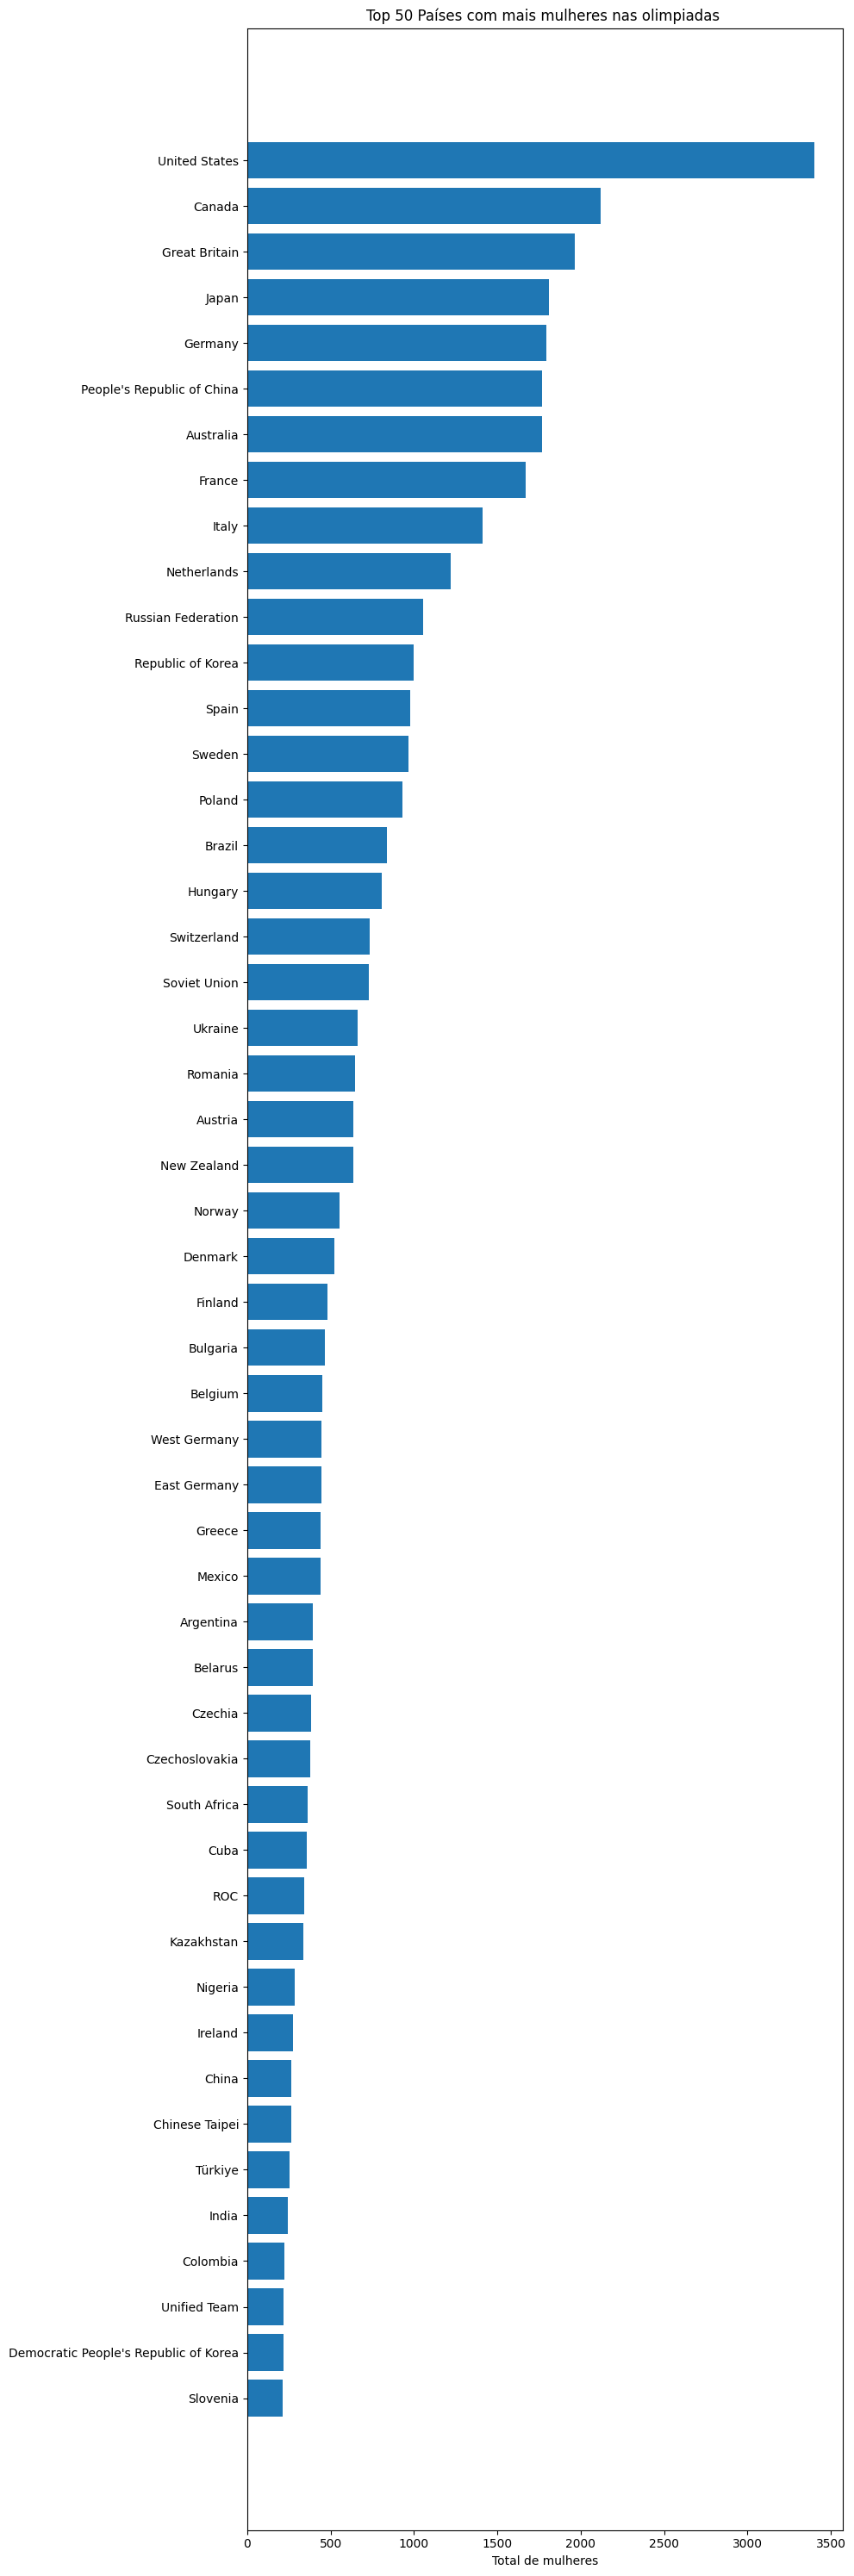

In [112]:
criar_grafico_50_top(sorted_female_values.head(50),"Female")

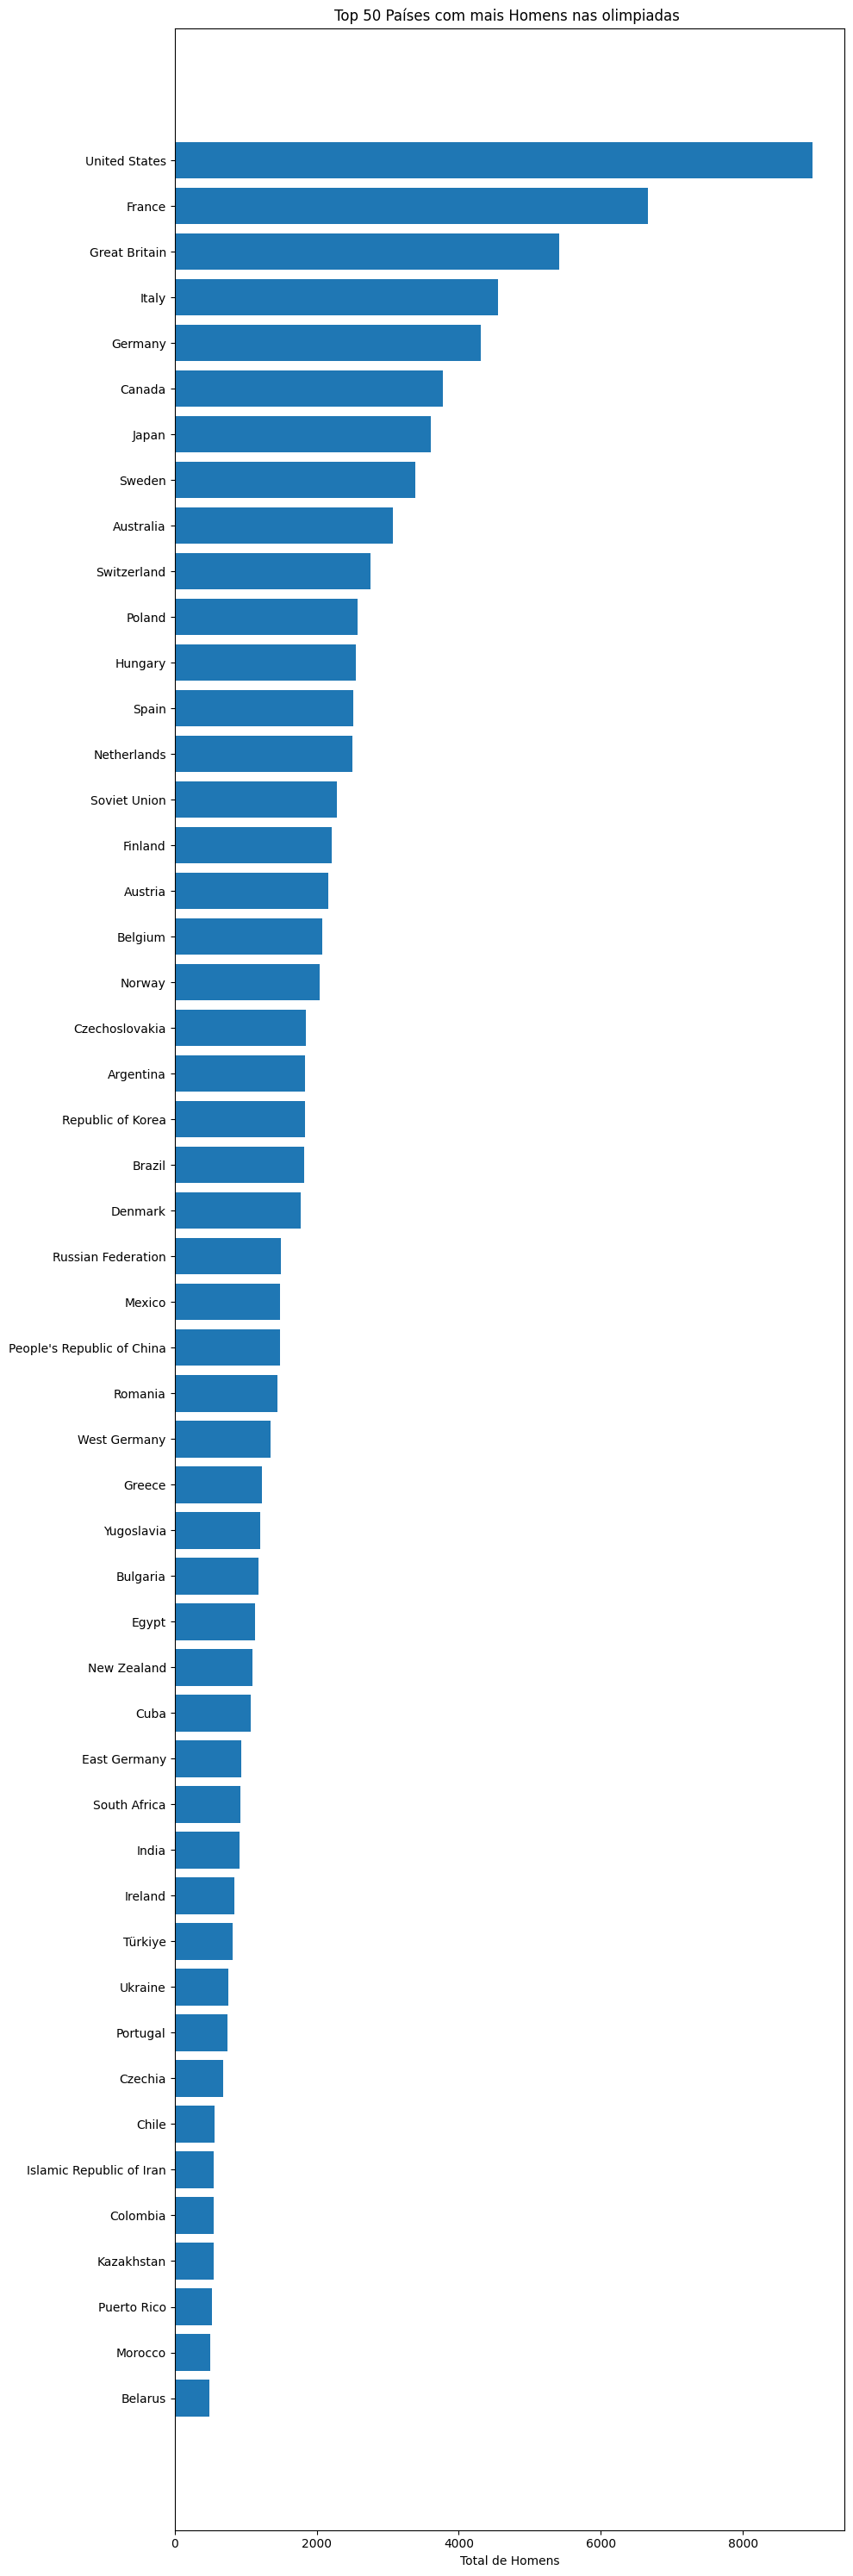

In [113]:
sorted_male_values = processed_values.sort_values("Male",ascending=False)
criar_grafico_50_top(sorted_male_values.head(50),"Male")

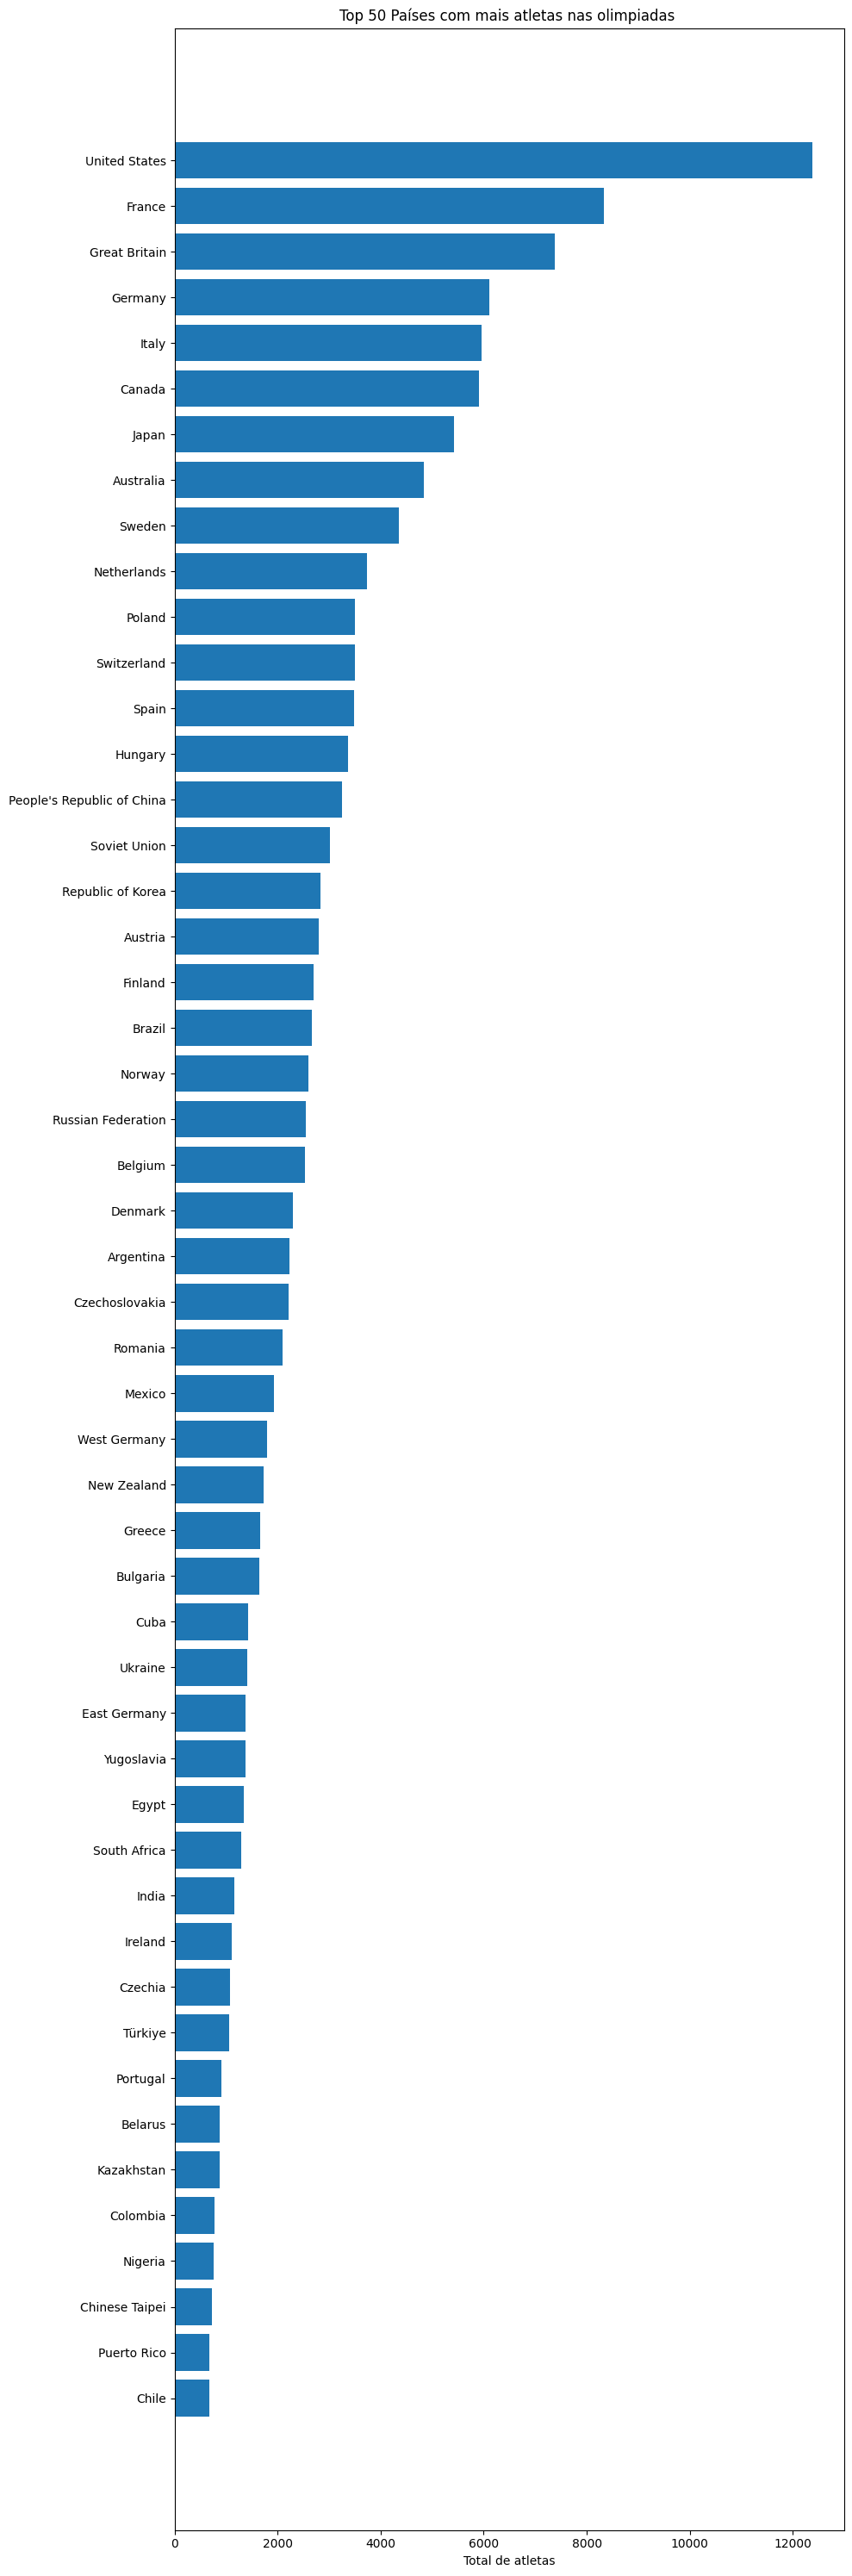

In [114]:
sorted_overall_values = processed_values.sort_values("Total",ascending=False)
criar_grafico_50_top(sorted_overall_values.head(50),"Total")